In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error, root_mean_squared_error

In [2]:
df = pd.read_csv("./car_price_decision_tree_dataset.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(3000, 9)

In [4]:
df.columns

Index(['Engine_CC', 'Mileage', 'Horsepower', 'Age', 'Brand', 'Fuel_Type',
       'Transmission', 'Condition', 'Price'],
      dtype='str')

In [5]:
df.head()

,Engine_CC,Mileage,Horsepower,Age,Brand,Fuel_Type,Transmission,Condition,Price
0,1660,25.1,117,16,Suzuki,Petrol,Automatic,10.0,772165
1,2094,9.0,244,15,Honda,Diesel,Manual,6.0,950518
2,1930,24.7,121,16,BMW,Petrol,Manual,4.0,922981
3,1895,24.9,225,11,Tata,Petrol,Manual,4.0,422660
4,2438,13.7,230,6,Honda,Petrol,Automatic,6.0,1118449


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Engine_CC         0
Mileage           0
Horsepower        0
Age               0
Brand             0
Fuel_Type         0
Transmission      0
Condition       250
Price             0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Engine_CC     3000 non-null   int64  
 1   Mileage       3000 non-null   float64
 2   Horsepower    3000 non-null   int64  
 3   Age           3000 non-null   int64  
 4   Brand         3000 non-null   str    
 5   Fuel_Type     3000 non-null   str    
 6   Transmission  3000 non-null   str    
 7   Condition     2750 non-null   float64
 8   Price         3000 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 211.1 KB


In [9]:
df.describe()

,Engine_CC,Mileage,Horsepower,Age,Condition,Price
count,3000.000000,3000.000000,3000.000000,3000.000000,2750.000000,3.000000e+03
mean,2147.550333,18.012533,205.352667,10.722333,7.041818,9.289151e+05
std,768.991603,5.738766,83.885910,5.722542,1.985047,3.739479e+05
min,801.000000,8.000000,60.000000,1.000000,4.000000,2.000000e+05
25%,1496.750000,13.100000,132.000000,6.000000,5.000000,6.656185e+05
50%,2137.000000,18.100000,205.000000,11.000000,7.000000,8.619240e+05
75%,2803.000000,23.000000,277.000000,16.000000,9.000000,1.123362e+06
max,3500.000000,28.000000,350.000000,20.000000,10.000000,2.602300e+06


## 2. Finding a way to handle missing values

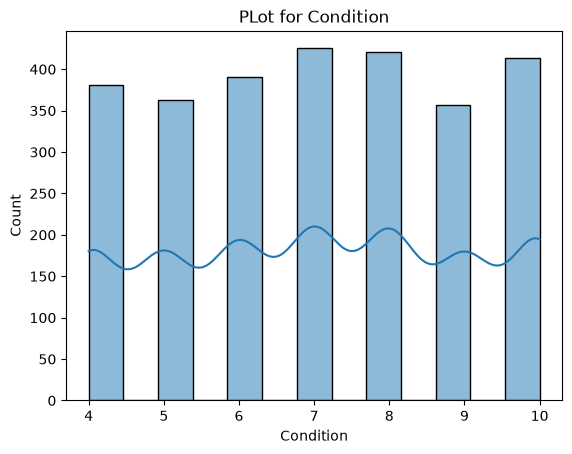

In [10]:
sns.histplot(df["Condition"], kde=True)
plt.title("PLot for Condition")
plt.show()

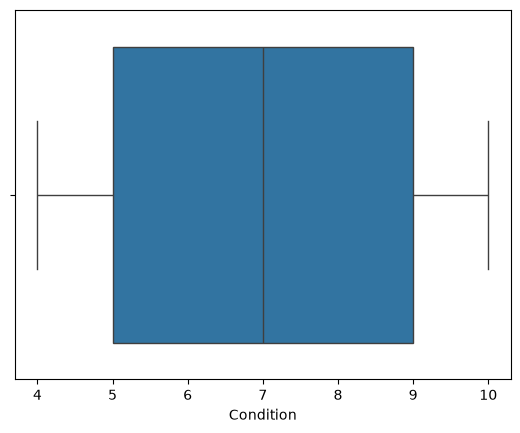

In [11]:
sns.boxplot(x=df["Condition"])
plt.show()

Choosing mean to impute the values because the distribution is pretty balanced

In [12]:
dfcopy = df.copy()

In [14]:
dfcopy["Condition"] = dfcopy["Condition"].fillna(dfcopy["Condition"].mean())

dfcopy.isnull().sum()

Engine_CC       0
Mileage         0
Horsepower      0
Age             0
Brand           0
Fuel_Type       0
Transmission    0
Condition       0
Price           0
dtype: int64

## 3. Outlier analysis

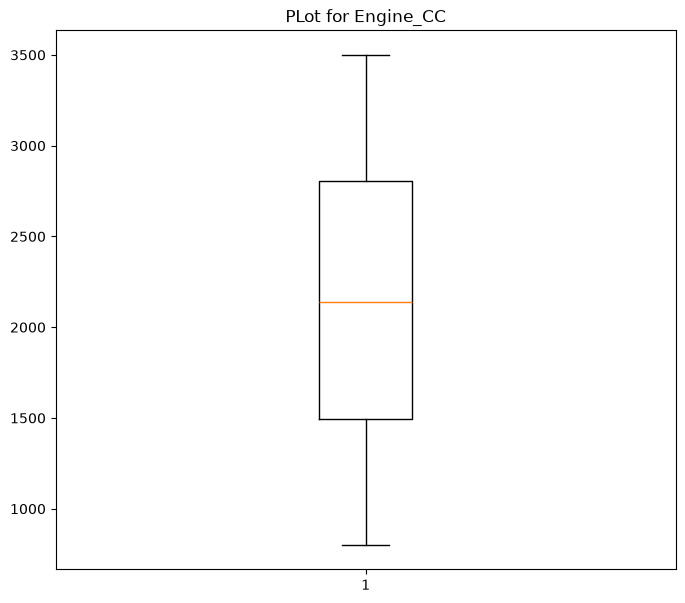

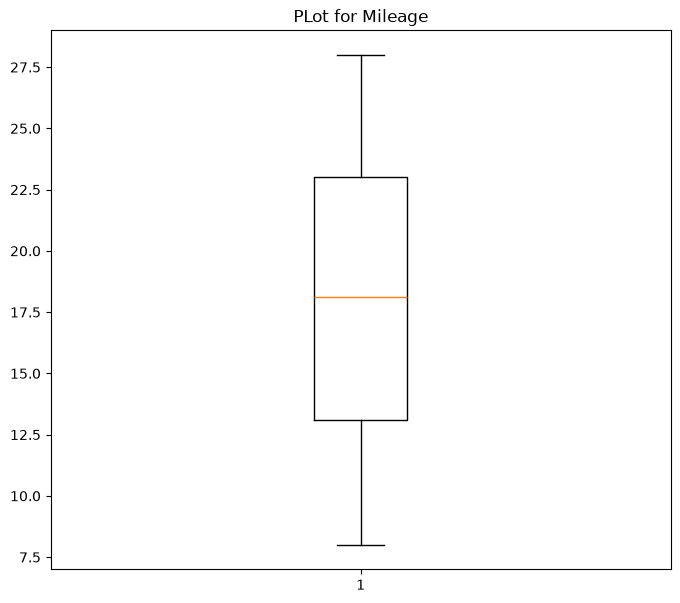

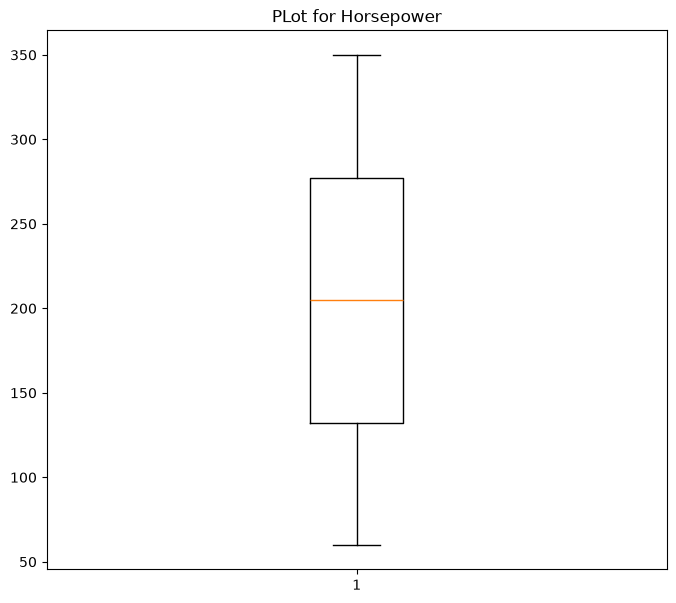

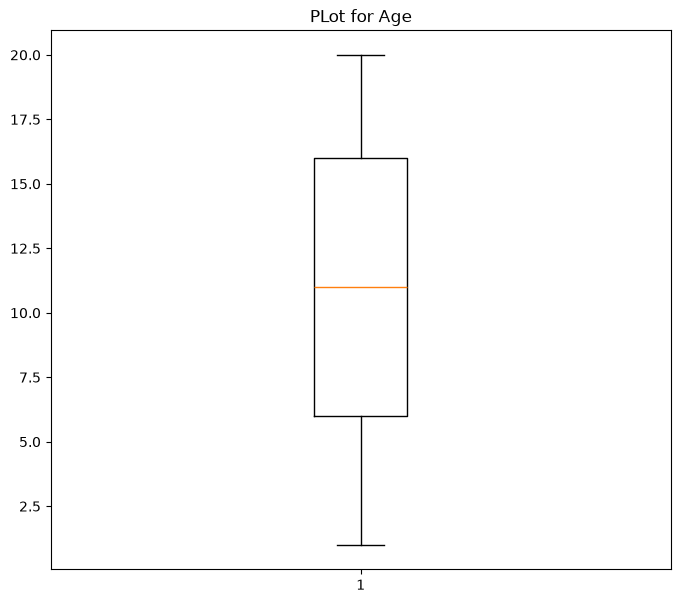

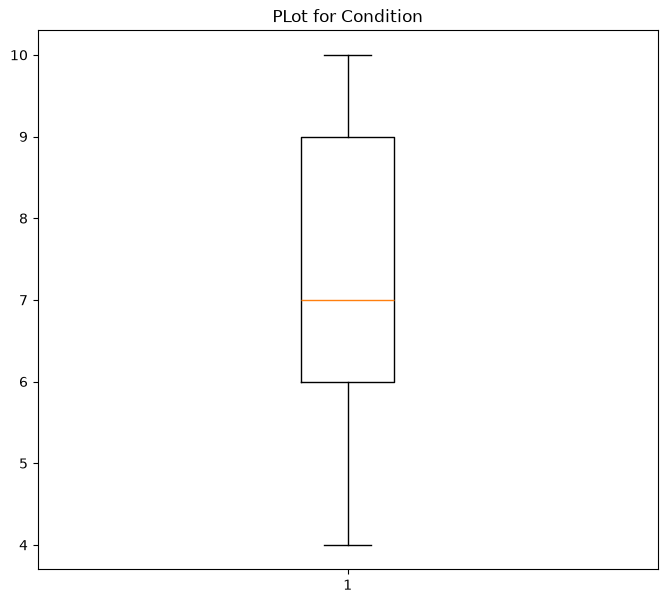

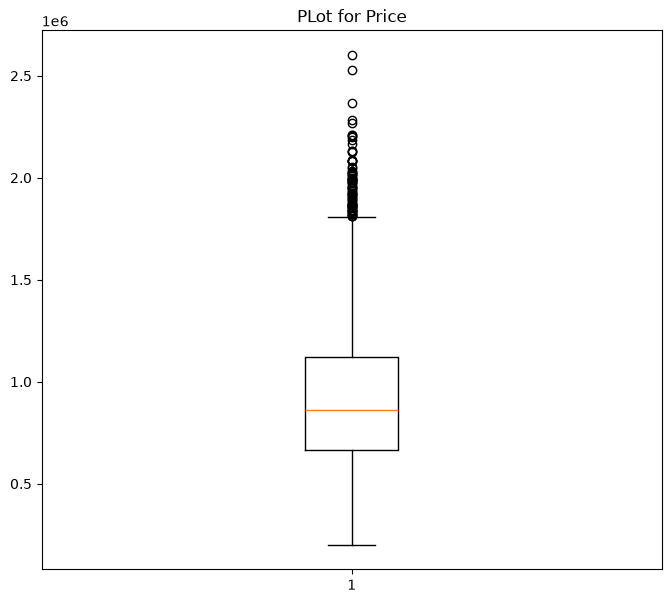

In [18]:
numeric_col = dfcopy.select_dtypes(include="number")

for col in numeric_col:
    plt.figure(figsize=(8,7))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"PLot for {col}")
    plt.show()

## 4. Encoding the categorical values into numerical values

In [22]:
dfcopy.select_dtypes(include="str").columns

Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='str')

In [27]:
dfcopy["Transmission"].unique()

<StringArray>
['Automatic', 'Manual']
Length: 2, dtype: str

Label encoding the transmission because of binary values

In [28]:
le = LabelEncoder()

dfcopy["Transmission"] = le.fit_transform(dfcopy["Transmission"])

In [29]:
dfcopy["Transmission"].unique()

array([0, 1])

One Hot encoding the fuel type and the brand columns because multiple categories

In [30]:
dfcopy = pd.get_dummies(dfcopy, columns=["Fuel_Type"], drop_first=True)

dfcopy.head()

,Engine_CC,Mileage,Horsepower,Age,Brand,Transmission,Condition,Price,Fuel_Type_Diesel,Fuel_Type_Petrol
0,1660,25.1,117,16,Suzuki,0,10.0,772165,False,True
1,2094,9.0,244,15,Honda,1,6.0,950518,True,False
2,1930,24.7,121,16,BMW,1,4.0,922981,False,True
3,1895,24.9,225,11,Tata,1,4.0,422660,False,True
4,2438,13.7,230,6,Honda,0,6.0,1118449,False,True


In [31]:
dfcopy = pd.get_dummies(dfcopy, columns=["Brand"], drop_first=True)

dfcopy.head()

,Engine_CC,Mileage,Horsepower,Age,Transmission,Condition,Price,Fuel_Type_Diesel,Fuel_Type_Petrol,Brand_BMW,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Suzuki,Brand_Tata,Brand_Toyota
0,1660,25.1,117,16,0,10.0,772165,False,True,False,False,False,False,True,False,False
1,2094,9.0,244,15,1,6.0,950518,True,False,False,True,False,False,False,False,False
2,1930,24.7,121,16,1,4.0,922981,False,True,True,False,False,False,False,False,False
3,1895,24.9,225,11,1,4.0,422660,False,True,False,False,False,False,False,True,False
4,2438,13.7,230,6,0,6.0,1118449,False,True,False,True,False,False,False,False,False


## 5. Preparing the data for the model

In [32]:
X = dfcopy.drop("Price", axis=1)
y = dfcopy["Price"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2400, 15)
(600, 15)
(2400,)
(600,)


## 6. Training the model

In [35]:
model = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

## 7. Model evaluation

In [36]:
pred = model.predict(X_test)

In [37]:
print("R2 score: ", r2_score(y_test, pred))
print("Mean absolute error: ", mean_absolute_error(y_test, pred))
print("Mean squared error: ", mean_squared_error(y_test, pred))
print("Root mean squared error: ", root_mean_squared_error(y_test, pred))

R2 score:  0.4907703978383884
Mean absolute error:  202356.17090196695
Mean squared error:  73667094264.15776
Root mean squared error:  271416.8275257777


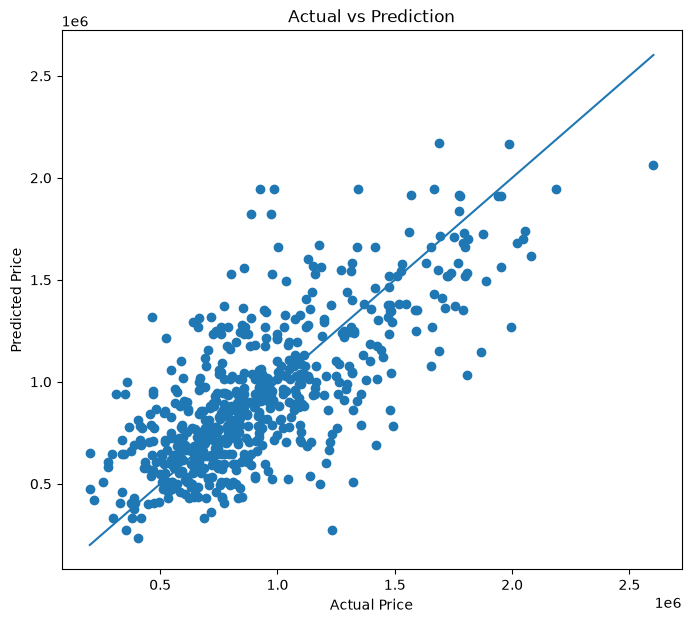

In [38]:
plt.figure(figsize=(8,7))
plt.scatter(y_test,pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

## 8. Model Improvements

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

         Feature  Importance
8      Brand_BMW    0.270560
0      Engine_CC    0.175035
2     Horsepower    0.121477
3            Age    0.114541
1        Mileage    0.041620
12  Brand_Suzuki    0.041390
5      Condition    0.038243
4   Transmission    0.033593
13    Brand_Tata    0.033097
14  Brand_Toyota    0.031231


In [42]:
train_pred = model.predict(X_train)

print(r2_score(y_train, train_pred))
print(r2_score(y_test, pred))

0.9053023157878887
0.4907703978383884


The r2 score for the training data is very good but for the model prediction its bad. This means that the model is over-fitting

In [43]:
test_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

test_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [45]:
train_pred = test_model.predict(X_train)

print(r2_score(y_train, train_pred))
print(r2_score(y_test, pred))

0.5293265748242516
0.4907703978383884


In [49]:
dfcopy["Price"].describe()

count    3.000000e+03
mean     9.289151e+05
std      3.739479e+05
min      2.000000e+05
25%      6.656185e+05
50%      8.619240e+05
75%      1.123362e+06
max      2.602300e+06
Name: Price, dtype: float64

In [48]:
corr = dfcopy.select_dtypes(include="number").corr()

print(corr["Price"].sort_values(ascending=False))

Price           1.000000
Engine_CC       0.346200
Horsepower      0.256803
Condition       0.161619
Mileage         0.006321
Transmission   -0.197959
Age            -0.304379
Name: Price, dtype: float64


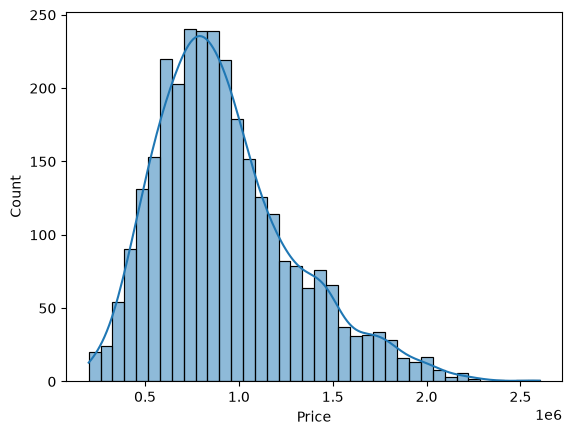

In [50]:
sns.histplot(dfcopy["Price"], kde=True)
plt.show()

In [51]:
df_cleaned = dfcopy.copy()

upper = df_cleaned["Price"].quantile(0.99)

df_cleaned = df_cleaned[df_cleaned["Price"] <= upper]

In [ ]:
X = df_cleaned.drop("price", axis=1)
y = df_cleaned["price"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [68]:
new_model = DecisionTreeRegressor(
    max_depth= 10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

new_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [69]:
train_pred = new_model.predict(X_train)
test_pred = new_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.7804969060789009
Test R² : 0.5333165058613394
